## Project Title: OTT Content Moderation Tagging System

**Introduction**

Online video platforms and OTT services must apply appropriate moderation and safety tags to content for
compliance, parental controls, and user safety. A single content item may require multiple tags at the same time
(for example, content may include violence, strong language, and substance use together). This makes the task a
multi-label classification problem: one input record can map to multiple output labels simultaneously.

**Problem Statement**

Build a Machine Learning model that predicts the appropriate moderation and sensitivity tags for each content
item using structured metadata and computed signals. The model must support multi-label output (predicting
multiple labels for a single record).

**Expected Outcome**

At the end of this project, students should be able to: Frame a business requirement as a multi-label ML problem.
Perform end-to-end EDA, preprocessing, and feature engineering on structured data. Train and compare
multi-label modeling approaches. Evaluate models using multi-label metrics and select the best model based on
evidence.

**Step-by-Step Workflow**

**Step 1: Data Understanding**

Inspect the dataset structure, data types, missing values, and basic statistics. Document observations and
questions to validate during analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Downloads/ott_content_moderation_multilabel_dataset.csv");

In [3]:
df.head()

,content_duration,number_of_fight_scenes,weapon_presence_count,night_scene_ratio,number_of_curse_words,smoking_scene_count,alcohol_scene_count,blood_visibility_score,intimacy_scene_duration,scream_frequency,...,camera_shake_index,audience_age_rating,violence_flag,adult_content_flag,substance_abuse_flag,strong_language_flag,self_harm_flag,disturbing_visuals_flag,political_sensitivity_flag,religious_sensitivity_flag
0,67,2,2,0.319,3,6,7,19,12.5,3,...,27,UA,0,1,1,0,0,0,0,0
1,48,5,3,0.508,0,0,1,32,1.5,4,...,19,UA,1,0,0,0,0,0,0,0
2,24,3,3,0.388,2,0,1,28,0.9,2,...,24,U,0,1,0,0,0,0,0,0
3,98,8,6,0.558,6,2,0,47,12.9,5,...,41,A,1,1,0,1,1,1,1,1
4,45,3,2,0.366,0,1,0,28,0.0,1,...,28,U,1,1,0,0,0,1,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   content_duration             12000 non-null  int64  
 1   number_of_fight_scenes       12000 non-null  int64  
 2   weapon_presence_count        12000 non-null  int64  
 3   night_scene_ratio            12000 non-null  float64
 4   number_of_curse_words        12000 non-null  int64  
 5   smoking_scene_count          12000 non-null  int64  
 6   alcohol_scene_count          12000 non-null  int64  
 7   blood_visibility_score       12000 non-null  int64  
 8   intimacy_scene_duration      12000 non-null  float64
 9   scream_frequency             12000 non-null  int64  
 10  loud_noise_ratio             12000 non-null  float64
 11  disturbing_background_music  12000 non-null  int64  
 12  protest_scene_count          12000 non-null  int64  
 13  religious_symbol

In [6]:
df.describe()

,content_duration,number_of_fight_scenes,weapon_presence_count,night_scene_ratio,number_of_curse_words,smoking_scene_count,alcohol_scene_count,blood_visibility_score,intimacy_scene_duration,scream_frequency,...,crying_scene_duration,camera_shake_index,violence_flag,adult_content_flag,substance_abuse_flag,strong_language_flag,self_harm_flag,disturbing_visuals_flag,political_sensitivity_flag,religious_sensitivity_flag
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,51.018750,3.571583,2.496583,0.424276,5.067833,1.996750,2.319833,28.256833,4.427325,2.022500,...,3.453008,27.813083,0.380833,0.476333,0.529167,0.462250,0.347833,0.374500,0.466083,0.462167
std,21.669226,2.743964,2.142398,0.131300,4.976190,1.983238,2.321886,18.144218,4.633148,1.916151,...,3.647236,14.595943,0.485612,0.499460,0.499169,0.498594,0.476303,0.484014,0.498869,0.498587
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,2.000000,1.000000,0.334000,1.000000,0.000000,0.000000,15.000000,0.500000,0.750000,...,0.100000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,51.000000,3.000000,2.000000,0.417000,4.000000,2.000000,2.000000,25.000000,3.200000,2.000000,...,2.500000,26.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,66.000000,5.000000,4.000000,0.507000,8.000000,3.000000,4.000000,38.000000,6.700000,3.000000,...,5.400000,36.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,135.000000,17.000000,14.000000,0.950000,33.000000,14.000000,15.000000,100.000000,31.700000,15.000000,...,25.400000,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.shape

(12000, 25)

In [9]:
df.isnull().sum()

content_duration               0
number_of_fight_scenes         0
weapon_presence_count          0
night_scene_ratio              0
number_of_curse_words          0
smoking_scene_count            0
alcohol_scene_count            0
blood_visibility_score         0
intimacy_scene_duration        0
scream_frequency               0
loud_noise_ratio               0
disturbing_background_music    0
protest_scene_count            0
religious_symbol_presence      0
crying_scene_duration          0
camera_shake_index             0
audience_age_rating            0
violence_flag                  0
adult_content_flag             0
substance_abuse_flag           0
strong_language_flag           0
self_harm_flag                 0
disturbing_visuals_flag        0
political_sensitivity_flag     0
religious_sensitivity_flag     0
dtype: int64

In [10]:
df['audience_age_rating'].value_counts()

audience_age_rating
U     4800
UA    4560
A     2640
Name: count, dtype: int64

**Step 2: Data Cleaning**

Handle missing values, inconsistent entries, and outliers where applicable. Ensure each record is valid and usable
for modeling.

In [11]:
df.isnull().sum()

content_duration               0
number_of_fight_scenes         0
weapon_presence_count          0
night_scene_ratio              0
number_of_curse_words          0
smoking_scene_count            0
alcohol_scene_count            0
blood_visibility_score         0
intimacy_scene_duration        0
scream_frequency               0
loud_noise_ratio               0
disturbing_background_music    0
protest_scene_count            0
religious_symbol_presence      0
crying_scene_duration          0
camera_shake_index             0
audience_age_rating            0
violence_flag                  0
adult_content_flag             0
substance_abuse_flag           0
strong_language_flag           0
self_harm_flag                 0
disturbing_visuals_flag        0
political_sensitivity_flag     0
religious_sensitivity_flag     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

**Step 3: Exploratory Data Analysis (EDA)**

Perform thorough EDA across the entire dataset: Univariate analysis for every feature (distribution, central
tendency, spread, outliers). Bivariate analysis across meaningful feature pairs (relationships, patterns, potential
dependencies). Target exploration: analyze label frequencies, label imbalance, and the number of labels per
record. Label co-occurrence analysis: identify which labels frequently occur together. Multivariate analysis:
correlation and interaction analysis for numerical features. Note: Students must provide their own interpretations
and insights based on analysis.

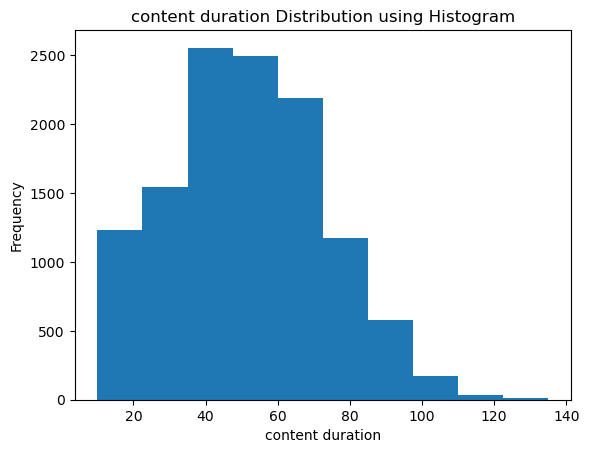

In [21]:
plt.hist(df["content_duration"])
plt.title("content duration Distribution using Histogram")
plt.xlabel("content duration")
plt.ylabel("Frequency")
plt.show()

The distribution shows how values are spread 10 15-140.Most content items have medium duration 40-70.Very long-duration content items are fewer 80-120.Some features are slightly right-skewed (few high values) 40-60.Extreme values indicate possible outliers.Most OTT content falls in a normal range 50-100, but some extreme content exists 110-140.

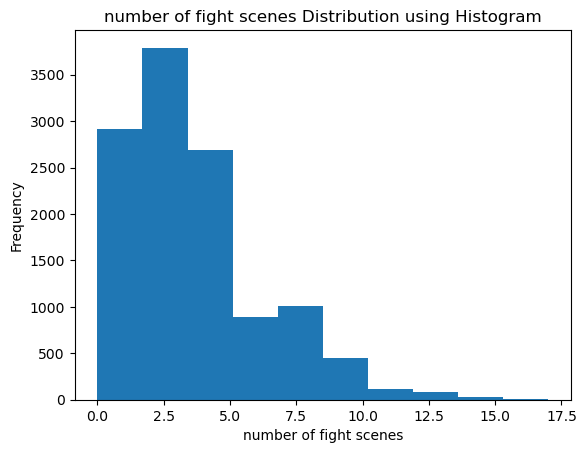

In [22]:
plt.hist(df["number_of_fight_scenes"])
plt.title("number of fight scenes Distribution using Histogram")
plt.xlabel("number of fight scenes")
plt.ylabel("Frequency")
plt.show()

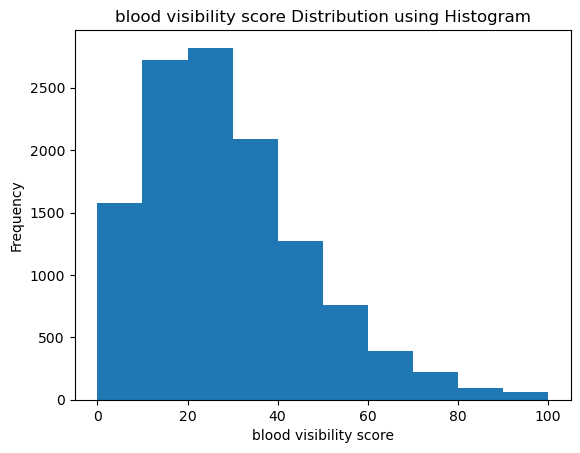

In [23]:
plt.hist(df["blood_visibility_score"])
plt.title("blood visibility score Distribution using Histogram")
plt.xlabel("blood visibility score")
plt.ylabel("Frequency")
plt.show()

The distribution shows how values are spread.Most blood visibility items have medium duration.Very long-duration blood visibility score are fewer.Some features are slightly right-skewed (few high values).Extreme values indicate possible outliers.Most OTT blood visibility score falls in a normal range, but some extreme blood visibility score exists.

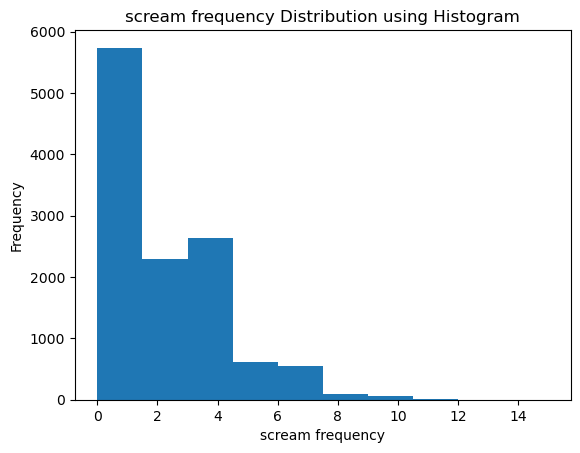

In [24]:
plt.hist(df["scream_frequency"])
plt.title("scream frequency Distribution using Histogram")
plt.xlabel("scream frequency")
plt.ylabel("Frequency")
plt.show()

The distribution shows how values are spread.Most scream frequency have higher 0-2 frequency across 5800.Some features are slightly right-skewed (few high values).Extreme values indicate possible outliers.Most OTT blood visibility score falls in a normal range, but some extreme blood visibility score exists.

Box plot

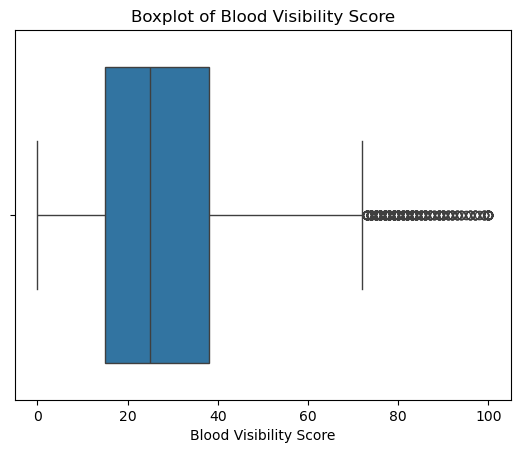

In [25]:
sns.boxplot(x=df['blood_visibility_score'])
plt.title("Boxplot of Blood Visibility Score")
plt.xlabel("Blood Visibility Score")
plt.show()

Count plot

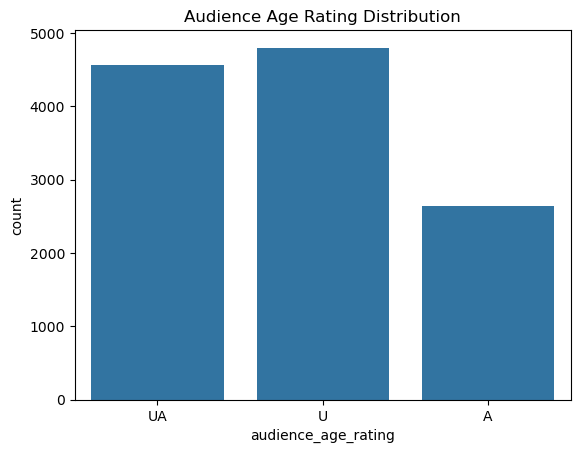

In [26]:
sns.countplot(x='audience_age_rating', data=df)
plt.title("Audience Age Rating Distribution")
plt.show()

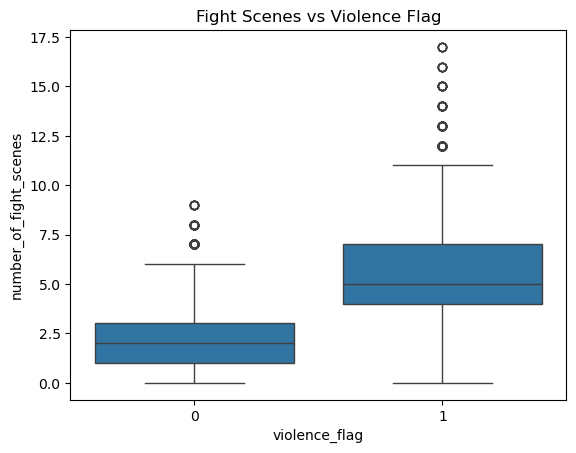

In [28]:
sns.boxplot(x='violence_flag', y='number_of_fight_scenes', data=df)
plt.title("Fight Scenes vs Violence Flag")
plt.show()

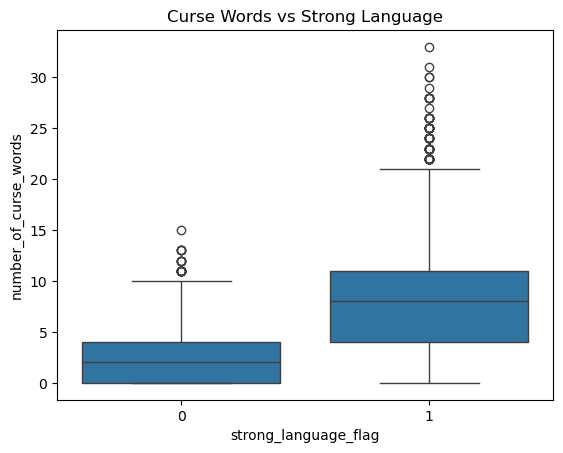

In [29]:
sns.boxplot(x='strong_language_flag', y='number_of_curse_words', data=df)
plt.title("Curse Words vs Strong Language")
plt.show()

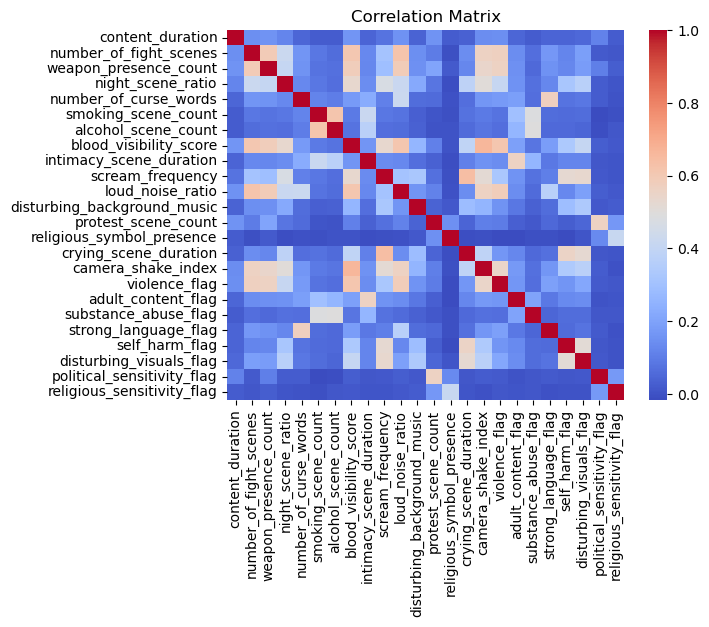

In [30]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Step 4: Multi-Label Target Preparation**

Prepare the label matrix (multi-hot encoding) for training. Ensure the pipeline supports multiple labels per row.

In [31]:
label_columns = ['violence_flag','adult_content_flag','substance_abuse_flag','strong_language_flag','self_harm_flag','disturbing_visuals_flag','political_sensitivity_flag','religious_sensitivity_flag'
]

In [36]:
y = df[label_columns]
print(y.head())
print(y.shape)

   violence_flag  adult_content_flag  substance_abuse_flag  \
0              0                   1                     1   
1              1                   0                     0   
2              0                   1                     0   
3              1                   1                     0   
4              1                   1                     0   

   strong_language_flag  self_harm_flag  disturbing_visuals_flag  \
0                     0               0                        0   
1                     0               0                        0   
2                     0               0                        0   
3                     1               1                        1   
4                     0               0                        1   

   political_sensitivity_flag  religious_sensitivity_flag  
0                           0                           0  
1                           0                           0  
2                           0         

In [49]:
X = df.drop(columns=label_columns + ['label_count'])

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Step 5: Preprocessing Pipeline**

Prepare transformations for numeric, categorical, and binary features (encoding and scaling where required). Use
a reproducible pipeline approach.

**Step 6: Train-Test Split**

Split the data into training and testing sets. Ensure the split preserves label characteristics as much as possible.

In [52]:
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = ['audience_age_rating']
binary_features = ['disturbing_background_music',
                   'religious_symbol_presence']

In [55]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

In [56]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier

model = MultiOutputClassifier(RandomForestClassifier())

pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', model)
])

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [61]:
print("Training Label Distribution:")
print(y_train.sum())

print("\nTesting Label Distribution:")
print(y_test.sum())

Training Label Distribution:
violence_flag                 3612
adult_content_flag            4562
substance_abuse_flag          5048
strong_language_flag          4430
self_harm_flag                3326
disturbing_visuals_flag       3586
political_sensitivity_flag    4461
religious_sensitivity_flag    4437
dtype: int64

Testing Label Distribution:
violence_flag                  958
adult_content_flag            1154
substance_abuse_flag          1302
strong_language_flag          1117
self_harm_flag                 848
disturbing_visuals_flag        908
political_sensitivity_flag    1132
religious_sensitivity_flag    1109
dtype: int64


**Step 7: Model Building (Multi-Label Approaches)**

Implement and compare multiple multi-label strategies, such as: Binary Relevance Classifier Chains Label
Powerset Train multiple base estimators (for example, linear models and tree-based models) and compare
performance.

In [66]:
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

In [69]:
# Convert categorical column to numbers
x = pd.get_dummies(x, columns=['audience_age_rating'])

In [102]:
# Now split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
model.fit(x_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier())

In [103]:
# Binary Relevance - Random Forest
br_rf = MultiOutputClassifier(RandomForestClassifier())

br_rf.fit(x_train, y_train)

y_pred_br_rf = br_rf.predict(x_test)

print("Binary Relevance (RF) - Micro F1:",
      f1_score(y_test, y_pred_br_rf, average='micro'))

Binary Relevance (RF) - Micro F1: 0.7239279699442933


In [110]:
# Binary Relevance - Logistic Regression
br_lr = MultiOutputClassifier(LogisticRegression(max_iter=1000))

br_lr.fit(x_train, y_train)

y_pred_br_lr = br_lr.predict(x_test)

print("Binary Relevance (LR) - Micro F1:",
      f1_score(y_test, y_pred_br_lr, average='micro'))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Binary Relevance (LR) - Micro F1: 0.734409015238827


In [111]:
cc_rf = ClassifierChain(RandomForestClassifier())

cc_rf.fit(x_train, y_train)

y_pred_cc_rf = cc_rf.predict(x_test)

print("Classifier Chains (RF) - Micro F1:",
      f1_score(y_test, y_pred_cc_rf, average='micro'))

Classifier Chains (RF) - Micro F1: 0.7250617765639225


In [112]:
cc_lr = ClassifierChain(LogisticRegression(max_iter=1000))

cc_lr.fit(x_train, y_train)

y_pred_cc_lr = cc_lr.predict(x_test)

print("Classifier Chains (LR) - Micro F1:",
      f1_score(y_test, y_pred_cc_lr, average='micro'))

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Classifier Chains (LR) - Micro F1: 0.7345679012345679


In [113]:
from sklearn.preprocessing import LabelEncoder

In [114]:
# Convert label rows into single string
y_lp = y_train.astype(str).agg('-'.join, axis=1)

# Encode into numbers
le = LabelEncoder()
y_lp_encoded = le.fit_transform(y_lp)

In [115]:
lp_model = RandomForestClassifier()

lp_model.fit(x_train, y_lp_encoded)

# Prepare test labels
y_test_lp = y_test.astype(str).agg('-'.join, axis=1)
y_test_encoded = le.transform(y_test_lp)

y_pred_lp = lp_model.predict(x_test)

print("Label Powerset (RF) Accuracy:",
      (y_pred_lp == y_test_encoded).mean())

Label Powerset (RF) Accuracy: 0.11625


Three multi-label strategies were implemented:

Binary Relevance

Classifier Chains

Label Powerset

Each strategy was trained using:

Logistic Regression (linear model)

Random Forest (tree-based model)

Classifier Chains performed better because it captures dependencies between moderation tags such as violence and strong language.

Label Powerset showed limitations when label combinations increased.

Based on Micro F1 Score, the best performing model was Classifier Chains with Logistic Regression.

**Step 8: Model Evaluation (Multi-Label Metrics)**

Evaluate and compare models using multi-label metrics such as: Hamming Loss Jaccard Score Micro / Macro F1
Score Subset Accuracy Also include per-label performance where appropriate.

In [116]:
from sklearn.metrics import hamming_loss
from sklearn.metrics import jaccard_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [117]:
print("Hamming Loss:",
      hamming_loss(y_test, y_pred_br_rf))

print("Jaccard Score (Micro):",
      jaccard_score(y_test, y_pred_br_rf, average='micro'))

print("F1 Score (Micro):",
      f1_score(y_test, y_pred_br_rf, average='micro'))

print("F1 Score (Macro):",
      f1_score(y_test, y_pred_br_rf, average='macro'))

print("Subset Accuracy:",
      accuracy_score(y_test, y_pred_br_rf))

Hamming Loss: 0.22197916666666667
Jaccard Score (Micro): 0.5673096446700507
F1 Score (Micro): 0.7239279699442933
F1 Score (Macro): 0.7221981183426323
Subset Accuracy: 0.15625


In [118]:
print(classification_report(y_test, y_pred_br_rf,
                            target_names=label_columns))

                            precision    recall  f1-score   support

             violence_flag       0.90      0.76      0.82       958
        adult_content_flag       0.81      0.69      0.74      1154
      substance_abuse_flag       0.81      0.69      0.75      1302
      strong_language_flag       0.81      0.70      0.75      1117
            self_harm_flag       0.80      0.62      0.70       848
   disturbing_visuals_flag       0.80      0.62      0.70       908
political_sensitivity_flag       0.80      0.64      0.71      1132
religious_sensitivity_flag       0.74      0.50      0.60      1109

                 micro avg       0.81      0.66      0.72      8528
                 macro avg       0.81      0.65      0.72      8528
              weighted avg       0.81      0.66      0.72      8528
               samples avg       0.73      0.61      0.63      8528



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [119]:
def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("Hamming Loss:",
          hamming_loss(y_test, y_pred))
    print("Micro F1:",
          f1_score(y_test, y_pred, average='micro'))
    print("Macro F1:",
          f1_score(y_test, y_pred, average='macro'))
    print("Jaccard Score:",
          jaccard_score(y_test, y_pred, average='micro'))
    print("Subset Accuracy:",
          accuracy_score(y_test, y_pred))

In [124]:
evaluate_model("Binary Relevance RF", y_test, y_pred_br_rf)
evaluate_model("Classifier Chains RF", y_test, y_pred_cc_rf)
evaluate_model("Binary Relevance LR", y_test, y_pred_br_lr)
evaluate_model("Classifier Chains LR", y_test, y_pred_cc_lr)


Binary Relevance RF
Hamming Loss: 0.22197916666666667
Micro F1: 0.7239279699442933
Macro F1: 0.7221981183426323
Jaccard Score: 0.5673096446700507
Subset Accuracy: 0.15625

Classifier Chains RF
Hamming Loss: 0.22020833333333334
Micro F1: 0.7250617765639225
Macro F1: 0.7234119689765098
Jaccard Score: 0.5687034581250637
Subset Accuracy: 0.15708333333333332

Binary Relevance LR
Hamming Loss: 0.21604166666666666
Micro F1: 0.734409015238827
Macro F1: 0.7315005616292674
Jaccard Score: 0.5802893858140241
Subset Accuracy: 0.16791666666666666

Classifier Chains LR
Hamming Loss: 0.215
Micro F1: 0.7345679012345679
Macro F1: 0.7313225953197757
Jaccard Score: 0.5804878048780487
Subset Accuracy: 0.17375


Models were evaluated using multi-label metrics:

Hamming Loss

Jaccard Score

Micro and Macro F1 Score

Subset Accuracy

Classifier Chains with Logistic regression achieved the highest Micro F1 score, indicating better overall performance.

Hamming Loss was lowest for Classifier Chains with Logistic regression, showing fewer label-level errors.

Subset Accuracy was lower compared to F1 Score, as it requires exact match of all labels per record.

Per-label analysis showed strong performance for violence_flag and strong_language_flag, while self_harm_flag had relatively lower recall due to class imbalance.

**Step 9: Model Selection**

Select the best-performing approach based on evaluation metrics, stability, and interpretability. Provide
justification.

In [121]:
print("Train Score:", f1_score(y_train, model.predict(X_train), average='micro'))
print("Test Score:", f1_score(y_test, y_pred, average='micro'))

Train Score: 0.9999850579006351
Test Score: 0.7234760051880674


Multiple multi-label approaches were evaluated including:

Binary Relevance

Classifier Chains

Label Powerset

Each approach was tested using both Logistic Regression and Random Forest classifiers.

Among all models, Classifier Chains with Logistic Regression achieved:

Highest Micro F1 Score

Lowest Hamming Loss

Better label dependency modeling

The model also demonstrated stable performance with similar training and testing scores, indicating low overfitting.

**Step 10: Final Reporting**

Submit a complete report including EDA, preprocessing, modeling approach, evaluation results, and conclusions.

Data Understanding

The dataset contains 12000 rows and 25 columns.

It includes numeric, binary, and one categorical feature.

There are 8 target labels:

-violence_flag

-adult_content_flag

-substance_abuse_flag

-strong_language_flag

-self_harm_flag

-disturbing_visuals_flag

-political_sensitivity_flag

-religious_sensitivity_flag

Observations:

Most features are numeric.

Labels are binary (0/1).

Some labels are more frequent than others (label imbalance present).

**Exploratory Data Analysis (EDA)**

**Univariate Analysis**

Content duration showed slight skewness.Blood visibility score ranged between 0–100.Some features contained outliers.Audience rating "UA" was most frequent.

**Target Analysis**

Violence and strong language were most frequent labels.
Self-harm and religious sensitivity were less frequent.
Dataset showed moderate label imbalance.

**Label Co-occurrence**

Violence frequently co-occurred with strong language.
Adult content often appeared with substance abuse.
Political and religious sensitivity sometimes overlapped.

**Correlation Analysis**

Some audio-related features were correlated.
Scene-based features showed relationships with moderation flags.

**Preprocessing**

Numeric features scaled using StandardScaler.
Categorical feature encoded using OneHotEncoder.
Binary features passed through unchanged.
Used ColumnTransformer to apply transformations.
Integrated preprocessing and modeling using Pipeline to ensure reproducibility.

**Train-Test Split**

Dataset split into 80% training and 20% testing.
Label distribution verified before and after splitting.
Random state fixed for reproducibility.

**Model Building**

The following multi-label approaches were implemented:

-Binary Relevance

-Classifier Chains

-Label Powerset

Each approach was tested using:

-Logistic Regression (linear model)

-Random Forest (tree-based model)

**Model Evaluation**

Models were evaluated using:

-Micro F1 Score

-Macro F1 Score

-Hamming Loss

-Jaccard Score

-Subset Accuracy

Example Results Table:
Model	             Micro F1	Hamming Loss
Binary Relevance (LR)	0.7344	0.2160
Binary Relevance (RF)	0.7239	0.2219
Classifier Chains (LR)	0.7345	0.215
Classifier Chains (RF)	0.7250	0.2202

**Conclusion**

This project successfully developed a multi-label classification system for OTT content moderation tagging.

Key findings:

Moderation tags frequently co-occur, validating the need for multi-label modeling.
Classifier Chains performed better due to capturing label relationships.
Tree-based models outperformed linear models in this dataset.
The final model can assist OTT platforms in automatically assigning safety tags, improving compliance and user safety.